In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter
import os
import boto3
from io import StringIO
from dotenv import load_dotenv

In [2]:
load_dotenv()

aws_access_key = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
aws_region = os.getenv("AWS_REGION")

bucket_name = os.getenv("BUCKET_NAME")
object_key_processed = os.getenv("OBJECT_KEY_PROCESSED")

s3 = boto3.client(
    "s3",
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    region_name=aws_region
)

obj = s3.get_object(Bucket=bucket_name, Key=object_key_processed)
data = obj['Body'].read().decode('utf-8')

df_feat = pd.read_csv(StringIO(data))

print(f"XGBoost model loaded from s3://{bucket_name}/{object_key_processed}")

XGBoost model loaded from s3://customer-churn-prediction-project/processed/Processed-Telco-Customer-Churn.csv


In [ ]:
# from pathlib import Path
# import pandas as pd

# BASE_DIR = Path().resolve() 

# PROJECT_DIR = BASE_DIR.parent 

# file_path = PROJECT_DIR / 'data' / 'Processed-Telco-Customer-Churn.csv'

# # Load CSV
# df_feat = pd.read_csv(file_path)

# print(df_feat.head())

C:\Users\Avishka Koswaththa\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'colsample_bytree': 0.6375927759363476, 'gamma': 2.89140070498087, 'learning_rate': 0.020782682139022624, 'max_depth': 3, 'min_child_weight': 6, 'n_estimators': 413, 'subsample': 0.9441618473246701}
Optimal threshold by F1-score: 0.5899999999999997
--- Training Set ---
ROC AUC: 0.8753110351732156
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      4139
           1       0.60      0.76      0.67      1495

    accuracy                           0.80      5634
   macro avg       0.75      0.79      0.76      5634
weighted avg       0.82      0.80      0.81      5634

Confusion Matrix:
 [[3385  754]
 [ 366 1129]]


--- Test Set ---
ROC AUC: 0.8456909245911802
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                          

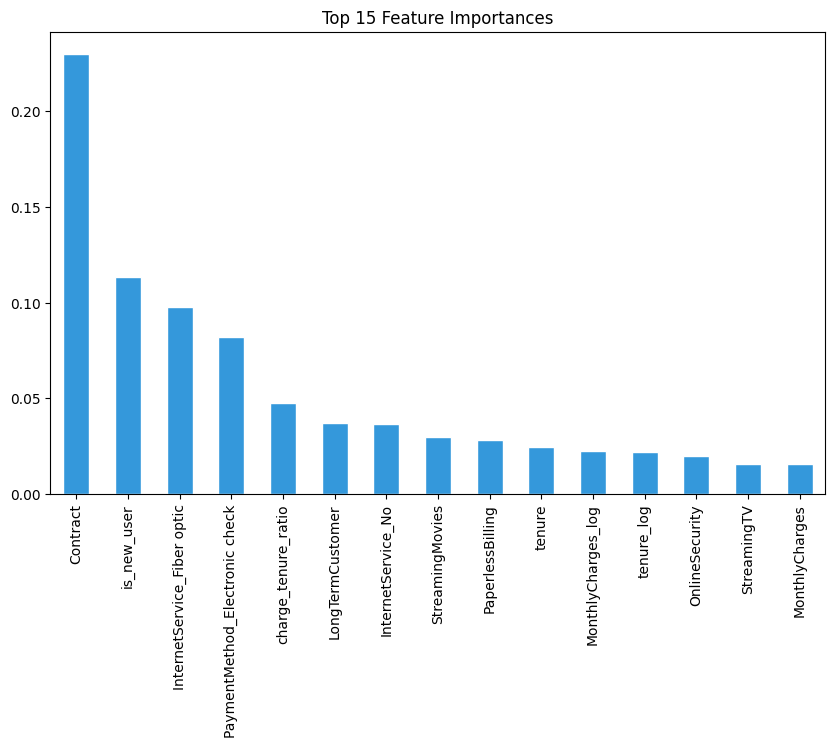

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

target_col = 'Churn'
feature_cols = [c for c in df_feat.columns if c != target_col]

X = df_feat[feature_cols].values
y = df_feat[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#XGBoost Hyperparameter Search

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',  
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])   
)

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_xgb = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)

y_proba_test = best_xgb.predict_proba(X_test)[:,1]

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.01)
for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Optimal threshold by F1-score:", best_threshold)
y_pred_test = (y_proba_test >= best_threshold).astype(int)


def evaluate(model, X, y, y_pred=None, dataset_name="Dataset"):
    if y_pred is None:
        y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:,1]
    print(f"--- {dataset_name} ---")
    print("ROC AUC:", roc_auc_score(y, y_proba))
    print(classification_report(y, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
    print("\n")

evaluate(best_xgb, X_train, y_train, 
         y_pred=(best_xgb.predict_proba(X_train)[:,1]>=best_threshold).astype(int),
         dataset_name="Training Set")
evaluate(best_xgb, X_test, y_test, y_pred=y_pred_test, dataset_name="Test Set")


feat_importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_importance[:15].plot(kind='bar', color='#3498db', edgecolor='white')
plt.title("Top 15 Feature Importances")
plt.show()


#### Save model to s3

In [4]:
from io import BytesIO
import joblib

load_dotenv()

aws_access_key = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_key = os.getenv("AWS_SECRET_ACCESS_KEY")
aws_region = os.getenv("AWS_REGION")
bucket_name = os.getenv("BUCKET_NAME")
model_object_key = os.getenv("XGB_MODEL_OBJECT_KEY")

# Initialize S3 client
s3 = boto3.client(
    "s3",
    aws_access_key_id=aws_access_key,
    aws_secret_access_key=aws_secret_key,
    region_name=aws_region
)

# Save model to an in-memory bytes buffer
model_buffer = BytesIO()
joblib.dump({
    "model": best_xgb,
    "threshold": best_threshold,
    "feature_cols": feature_cols
}, model_buffer)
model_buffer.seek(0)

# Upload to S3
s3.put_object(Bucket=bucket_name, Key=model_object_key, Body=model_buffer.getvalue())

print(f"XGBoost model saved to s3://{bucket_name}/{model_object_key}")

XGBoost model saved to s3://customer-churn-prediction-project/models/xgb/xgb_churn_model.pkl


In [ ]:
# import joblib
# from pathlib import Path


# BASE_DIR = Path().resolve()  

# PROJECT_DIR = BASE_DIR.parent 

# model_dir = PROJECT_DIR / "models"
# model_dir.mkdir(exist_ok=True)  

# model_filename = model_dir / "xgb_churn_model.pkl"

 
# joblib.dump({
#     "model": best_xgb,
#     "threshold": best_threshold,
#     "feature_cols": feature_cols   
# }, model_filename)

# print(f"Model and threshold saved to {model_filename}")

Model and threshold saved to E:\Users\Avishka\JobData\MyProjects\ml-model\models\xgb_churn_model.pkl
